In [1]:
import gc, torch
import os
os.environ["TORCHDYNAMO_DISABLE"]     = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"
gc.collect()
torch.cuda.empty_cache()

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"Free    : {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

torch.cuda.synchronize()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")
print("PyTorch:", torch.__version__)   # should be 2.12+cu130
print("CUDA:", torch.cuda.is_available())  # should be True now
print("GPU:", torch.cuda.get_device_name(0))

PyTorch : 2.10.0+cu128
CUDA    : True
Free    : 15.6 GB
Free VRAM: 15.6 GB
PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA H100 80GB HBM3 MIG 2g.20gb


In [2]:
%%bash
pip install transformers==4.40.0 --user -q
pip install accelerate --user -q
echo "Done"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Done


In [3]:
# -*- coding: utf-8 -*-
"""
HuBERT Fine-tuning on UASpeech with Phoneme-Level Data Augmentation
=====================================================================
Colab-ready — paste each CELL block into a separate Colab cell.

Pipeline:
  transcript → IPA (espeak-ng) → phoneme augmentation
  (substitution / deletion / prolongation) → TTS synthesis
  → augmented waveform → HuBERT CTC fine-tuning

Authors: Group 4 (adapted for phoneme-level augmentation)
"""

# =====================================================================
# CELL 1 — System & Python installs
# Run this first, then restart runtime if prompted.
# =====================================================================
'''!apt-get install -y espeak-ng libespeak-ng-dev
!pip install phonemizer
!pip install --user TTS
!pip install --user phonemizer

!pip uninstall -y torch torchaudio torchvision
!pip install --user --force-reinstall TTS phonemizer'''
!pip install eng_to_ipa
!pip install torch torchaudio transformers librosa jiwer kagglehub


  Using cached eng_to_ipa-0.0.2-py3-none-any.whl

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
  Using cached torchaudio-2.11.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached jiwer-4.0.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached kagglehub-1.0.1-py3-none-any.whl.metadata (40 kB)
  Using cached rapidfuzz-3.14.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (12 kB)
  Using cached kagglesdk-0.1.23-py3-none-any.whl.metadata (13 kB)
Using cached torchaudio-2.11.0-cp311-cp311-manylinux_2_28_x86_64.whl (1.8 MB)
Using cached jiwer-4.0.0-py3-none-any.whl (23 kB)
Using cached kagglehub-1.0.1-py3-none-any.whl (70 kB)
Using cached kagglesdk-0.1.23-py3-none-any.whl (217 kB)
Using cached rapidfuzz-3.14.5-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (3.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [kagglehub]/5 [kagglehub]

[notice] A new release of pip is av

In [4]:
# =====================================================================
# CELL 2 — Download UASpeech dataset from Kaggle
# =====================================================================

import kagglehub
from pathlib import Path
import os

path = kagglehub.dataset_download("aryashah2k/noise-reduced-uaspeech-dysarthria-dataset")
print("Dataset root:", path)

# Inspect folder layout
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:5]:
            print(f'{indent}  {f}')


Dataset root: /home/jovyan/.cache/kagglehub/datasets/aryashah2k/noise-reduced-uaspeech-dysarthria-dataset/versions/1
1/
  noisereduced-uaspeech-control/
    CF05/
      CF05_B3_UW87_M5.wav
      CF05_B1_UW15_M3.wav
      CF05_B1_CW43_M2.wav
      CF05_B3_CW38_M5.wav
      CF05_B3_UW24_M4.wav
    CM04/
      CM04_B2_UW63_M5.wav
      CM04_B1_CW96_M4.wav
      CM04_B1_CW48_M8.wav
      CM04_B3_UW1_M8.wav
      CM04_B2_UW88_M2.wav
    CM08/
      CM08_B2_LG_M4.wav
      CM08_B2_C2_M3.wav
      CM08_B2_LF_M3.wav
      CM08_B1_LH_M7.wav
      CM08_B2_CW13_M4.wav
    CF04/
      CF04_B1_LB_M4.wav
      CF04_B2_UW87_M2.wav
      CF04_B2_CW75_M6.wav
      CF04_B3_CW54_M2.wav
      CF04_B2_CW48_M5.wav
    CF02/
      CF02_B3_UW60_M8.wav
      CF02_B1_UW67_M4.wav
      CF02_B1_CW13_M2.wav
      CF02_B2_C17_M4.wav
      CF02_B2_UW21_M3.wav
    CM12/
      CM12_B1_UW13_M8.wav
      CM12_B3_UW24_M6.wav
      CM12_B1_CW88_M5.wav
      CM12_B1_CW84_M5.wav
      CM12_B2_CW53_M5.wav
    CM01/
      CM0

In [5]:
# =====================================================================
# CELL 3 — All imports
# =====================================================================
import gc
import os
import re
import random
import numpy as np
import librosa
import torch
import torch.nn.functional as F
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional
import eng_to_ipa as ipa_converter
from torch.utils.data import Dataset, DataLoader
from transformers import (
    HubertForCTC,
    Wav2Vec2Processor,
    get_linear_schedule_with_warmup,
)
from jiwer import wer, cer

print("All imports successful.")

All imports successful.


/home/jovyan/.local/lib/python3.11/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [6]:
# =====================================================================
# CELL 4 — Global Parameters
# =====================================================================

# ── Paths ─────────────────────────────────────────────────────────────
# Replace with your actual kagglehub path after Cell 2
# path = kagglehub.dataset_download("aryashah2k/noise-reduced-uaspeech-dysarthria-dataset")
DATASET_ROOT = Path(path)
OUTPUT_DIR   = "./checkpoints_phoneme"

# ── Training hyperparameters ──────────────────────────────────────────
POLICY           = "phoneme"   # none | phoneme
EPOCHS           = 3
BATCH_SIZE       = 2           # Keep at 1 for hubert-large; use GRAD_ACCUM for effective batch
GRAD_ACCUM_STEPS = 4           # Effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS
LR               = 3e-5
VAL_SPLIT        = 0.10
TEST_SPLIT       = 0.10
NUM_WORKERS      = 2           # 
SEED             = 42
TARGET_SR        = 16_000      # HuBERT expects 16 kHz

# ── Model ─────────────────────────────────────────────────────────────
MODEL_NAME = "facebook/hubert-large-ls960-ft"
# If you hit OOM even after the memory fixes, switch to:
# MODEL_NAME = "facebook/hubert-base-ls960-ft"

# ── Phoneme augmentation probabilities ───────────────────────────────
SUB_PROB = 0.15   # Probability of substituting each eligible phoneme
DEL_PROB = 0.10   # Probability of deleting each consonant
PRO_PROB = 0.10   # Probability of prolonging each vowel/sonorant


In [7]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Dataset
#
# The Kaggle noise-reduced UASpeech dataset layout:
#   <root>/
#     <speaker_id>/          e.g. CF02, CM01, M01 ...
#       <block>/             e.g. B1, B2, B3
#         <word_id>_<mic>.wav   e.g. UW1_M7.wav
#
# OR sometimes the full filename includes speaker:
#   CF02_B1_UW1_M7.wav
#
# We parse the word_id from the stem and look up the transcript.
# Files whose word_id is not in our vocabulary are skipped.
# ─────────────────────────────────────────────────────────────────────


import pandas as pd
from pathlib import Path
import re
import torch
import librosa
from torch.utils.data import Dataset
from typing import Optional, Dict

# =====================================================================
# 1. LOAD THE OFFICIAL DICTIONARY (CSV)
# =====================================================================
df_dict = pd.read_csv('dictionary_UASPEECH.csv')

OFFICIAL_MAPPING = {}
for index, row in df_dict.iterrows():
    word = str(row['WORD']).lower().strip()
    file_id = str(row['FILE NAME']).strip()
    OFFICIAL_MAPPING[file_id] = word

def get_official_transcript(filename):
    """Translates a UASpeech filename into the exact official transcript."""
    name = Path(filename).stem
    parts = name.split("_")
    
    if len(parts) < 3:
        # If it's a weird file, just return the name
        return name.lower()
        
    block = parts[1]      
    word_code = parts[2]  
    
    if word_code.startswith("UW"):
        lookup_key = f"{block}_{word_code}"
    elif word_code.startswith("A") and word_code[1:].isdigit():
        letter_index = int(word_code[1:]) - 1
        letter = chr(ord('A') + letter_index)
        lookup_key = f"L{letter}"
    else:
        lookup_key = word_code
        
    if lookup_key not in OFFICIAL_MAPPING:
        return word_code.lower()
        
    return OFFICIAL_MAPPING[lookup_key]


In [8]:
# =====================================================================
# CELL 6 — Phoneme-level augmentation engine
# =====================================================================

# ── Dysarthric substitution table ────────────────────────────────────
# Based on Xiong et al. (2019) and TORGO/UASpeech clinical literature.
# Most common patterns:
#   - Fricative stopping: /s/→/t/, /θ/→/t/ (very common)
#   - Liquid simplification: /r/→/w/, /l/→/w/
#   - Velar fronting: /k/→/t/, /g/→/d/
#   - Affricate reduction: /tʃ/→/t/
#   - Empty string "" = deletion of that phoneme

DYSARTHRIC_SUBSTITUTIONS: Dict[str, List[str]] = {
    # Fricatives → stops (stopping) or deletion
    "s":  ["t", "θ", ""],
    "z":  ["d", "s", ""],
    "ʃ":  ["s", "tʃ", ""],
    "ʒ":  ["dʒ", "ʃ", ""],
    "f":  ["p", "v", ""],
    "v":  ["b", "f", ""],
    "θ":  ["t", "d", "f"],     # th-stopping: most documented pattern
    "ð":  ["d", "v", ""],

    # Affricates → stops
    "tʃ": ["t", "ʃ"],
    "dʒ": ["d", "ʒ"],

    # Liquids → glides or deletion
    "r":  ["w", "l", ""],
    "l":  ["w", "r", ""],

    # Velar stops → alveolar (fronting)
    "k":  ["t", "g"],
    "g":  ["d", "k"],

    # Nasals — occasionally weakened
    "ŋ":  ["n", ""],
}

# IPA consonant set for deletion targeting
IPA_CONSONANTS = set("pbtdkɡfvszʃʒθðmnŋlrwjhʔtʃdʒ")

# IPA sonorants + vowels for prolongation targeting
IPA_SONORANTS = set("mnŋlrwjaeiouæɑɒɔəɛɜɪʊʌː")


def ipa_to_list(ipa_str: str) -> List[str]:
    """
    Split an IPA string into a list of phoneme tokens.
    Handles digraphs (tʃ, dʒ) before single characters.
    Strips spaces and keeps stress markers attached to their phoneme.
    """
    # Match digraphs first, then single IPA characters with optional stress/length
    pattern = r"(tʃ|dʒ|[ˈˌ]?[a-zæɑɒɔəɛɜɪʊʌθðʃʒŋɹɾʔːɡ]+)"
    tokens = re.findall(pattern, ipa_str)
    return [t for t in tokens if t.strip()]


def substitute_phonemes(phoneme_list: List[str], prob: float = SUB_PROB) -> List[str]:
    """
    Randomly substitute phonemes following the dysarthric table.
    Empty-string substitutions act as deletions.

    Args:
        phoneme_list: Input IPA phoneme tokens.
        prob: Per-phoneme probability of substitution.

    Returns:
        Augmented phoneme list (may be shorter due to deletion substitutions).
    """
    result = []
    n_substituted = 0
    for ph in phoneme_list:
        key = ph.lstrip("ˈˌ")  # strip stress markers for table lookup
        if key in DYSARTHRIC_SUBSTITUTIONS and random.random() < prob:
            replacement = random.choice(DYSARTHRIC_SUBSTITUTIONS[key])
            if replacement:
                result.append(replacement)
                n_substituted += 1
            # else: phoneme deleted via empty-string substitution
        else:
            result.append(ph)
    return result


def delete_phonemes(phoneme_list: List[str], prob: float = DEL_PROB) -> List[str]:
    """
    Randomly delete consonants to mimic phoneme omissions in dysarthric speech.
    Vowels are never deleted (vowel omission would make speech unintelligible).

    Args:
        phoneme_list: Input IPA phoneme tokens.
        prob: Per-consonant probability of deletion.

    Returns:
        Filtered phoneme list.
    """
    result = []
    for ph in phoneme_list:
        key = ph.lstrip("ˈˌ")
        # Only delete consonants, never vowels
        if key in IPA_CONSONANTS and random.random() < prob:
            pass  # deleted
        else:
            result.append(ph)
    return result


def prolong_phonemes(phoneme_list: List[str], prob: float = PRO_PROB) -> List[str]:
    """
    Duplicate sonorant/vowel phonemes to simulate dysarthric prolongations.
    In real dysarthric speech, vowels and nasals are often stretched.

    Args:
        phoneme_list: Input IPA phoneme tokens.
        prob: Per-sonorant probability of prolongation.

    Returns:
        Phoneme list with duplicated tokens where prolongation was applied.
    """
    result = []
    for ph in phoneme_list:
        result.append(ph)
        key = ph.lstrip("ˈˌ")
        # Prolong if any character in the phoneme is a sonorant/vowel
        if any(c in IPA_SONORANTS for c in key) and random.random() < prob:
            result.append(ph)  # duplication simulates lengthening
    return result


def apply_phoneme_augmentation(
    phoneme_list: List[str],
    do_substitution: bool = True,
    do_deletion: bool = True,
    do_prolongation: bool = True,
) -> List[str]:
    """
    Apply all three phoneme-level augmentations in the standard order:
      1. Substitution (may also delete via empty-string replacement)
      2. Deletion (explicit consonant removal)
      3. Prolongation (sonorant/vowel duplication)

    The order matters: substitution first ensures deletions are coherent,
    prolongation last prevents doubled phonemes from being re-deleted.

    Args:
        phoneme_list: Input IPA tokens.
        do_substitution / do_deletion / do_prolongation: Toggle each op.

    Returns:
        Augmented IPA token list.
    """
    if do_substitution:
        phoneme_list = substitute_phonemes(phoneme_list)
    if do_deletion:
        phoneme_list = delete_phonemes(phoneme_list)
    if do_prolongation:
        phoneme_list = prolong_phonemes(phoneme_list)
    return phoneme_list

# ── Improved IPA → plain English mapping ─────────────────────────────
# Tacotron2 LJSpeech only accepts plain ASCII English text
# We map augmented tokens back to simple English syllables

IPA_TO_APPROX_ENGLISH = {
    # Stops
    "p": "p",   "b": "b",   "t": "t",   "d": "d",
    "k": "k",   "ɡ": "g",   "g": "g",
    # Fricatives
    "f": "f",   "v": "v",   "θ": "th",  "ð": "th",
    "s": "s",   "z": "z",   "ʃ": "sh",  "ʒ": "zh",
    # Affricates
    "tʃ": "ch", "dʒ": "j",
    # Nasals
    "m": "m",   "n": "n",   "ŋ": "ng",
    # Liquids/glides
    "l": "l",   "r": "r",   "w": "w",   "j": "y",  "h": "h",
    # Vowels → simple ASCII approximations
    "æ": "a",   "ɑ": "ah",  "ɒ": "o",   "ɔ": "aw",
    "ə": "uh",  "ɛ": "eh",  "ɜ": "ur",  "ɪ": "ih",
    "ʊ": "uh",  "ʌ": "uh",
    "iː": "ee", "uː": "oo", "ɑː": "ah",
    "eɪ": "ay", "aɪ": "eye","ɔɪ": "oy", "aʊ": "ow",
    "oʊ": "oh",
    # Simple ASCII pass-through
    "a": "a",   "e": "e",   "i": "ee",  "o": "oh",  "u": "oo",
}

# Strip stress markers before lookup
STRESS = str.maketrans("", "", "ˈˌ")

def phoneme_list_to_approx_text(phoneme_list: List[str]) -> str:
    """
    Convert augmented IPA tokens to plain ASCII English for Tacotron2.
    Strips stress markers, maps IPA to approximate English spelling.
    Unknown tokens are dropped to avoid TTS vocabulary errors.
    """
    parts = []
    for ph in phoneme_list:
        # Strip stress markers
        key = ph.translate(STRESS).strip()
        if not key:
            continue
        # Try full token first, then character by character
        if key in IPA_TO_APPROX_ENGLISH:
            parts.append(IPA_TO_APPROX_ENGLISH[key])
        else:
            # Break into individual characters and map each
            mapped = "".join(
                IPA_TO_APPROX_ENGLISH.get(c, "")
                for c in key
            )
            if mapped:
                parts.append(mapped)
            # Unknown characters are silently dropped

    result = " ".join(parts)
    return result if result.strip() else "the"  # fallback to avoid empty string





In [9]:
# =====================================================================
# CELL 8 — Phonemizer backend (singleton, initialised once)
# =====================================================================

import eng_to_ipa as ipa_converter

class PhonemizerBackend:
    """
    Pure Python phonemizer — no espeak-ng system install needed.
    Uses eng_to_ipa which maps English words to IPA via a dictionary.
    """
    _instance = None

    def __new__(cls):
        if cls._instance is None:
            cls._instance = super().__new__(cls)
            print("Phonemizer ready (eng_to_ipa, no system deps).")
        return cls._instance

    def text_to_ipa(self, text: str) -> str:
        """
        Convert a plain English word or phrase to IPA.

        Args:
            text: Input English text.

        Returns:
            IPA string (e.g. "ækˈædəmɪk").
        """
        result = ipa_converter.convert(text.lower().strip())
        # eng_to_ipa marks unknown words with * — fall back to the word itself
        result = result.replace("*", text)
        return result


In [10]:
# =====================================================================
# CELL 9 — Full phoneme augmentation pipeline
# =====================================================================

def augment_phoneme_level(
    wav_path: Path,
    text: str,
    target_sr: int = TARGET_SR,
) -> np.ndarray:
    """
    Phoneme-level augmentation applied directly on the original waveform.
    No TTS required — effects are simulated acoustically:
      - Substitution → slight spectral noise
      - Deletion     → zero out random short segments  
      - Prolongation → repeat a middle segment

    This is acoustically valid: dysarthric phoneme errors manifest as
    distortions, silences, and prolongations in the waveform.
    """
    # Load original audio
    wav, _ = librosa.load(wav_path, sr=target_sr)

    # Get IPA and augment phoneme list
    ipa_str      = ipa_converter.convert(text.lower().strip()).replace("*", text)
    phoneme_list = ipa_to_list(ipa_str)
    aug_list     = apply_phoneme_augmentation(phoneme_list)

    deletion_ratio = 1.0 - (len(aug_list) / max(len(phoneme_list), 1))

    # Simulate deletion — zero out segments proportional to deleted phonemes
    if deletion_ratio > 0:
        n_zero = int(len(wav) * deletion_ratio * 0.5)
        if n_zero > 0:
            start = random.randint(0, max(0, len(wav) - n_zero))
            wav[start:start + n_zero] = 0.0

    # Simulate prolongation — repeat a middle chunk
    if random.random() < PRO_PROB:
        mid   = len(wav) // 2
        chunk = int(target_sr * 0.08)
        if mid + chunk < len(wav):
            wav = np.concatenate([wav[:mid], wav[mid:mid+chunk], wav[mid:]])

    # Simulate substitution distortion — add subtle noise
    if len(aug_list) != len(phoneme_list):
        wav = wav + np.random.randn(len(wav)).astype(np.float32) * 0.003

    wav = np.clip(wav, -1.0, 1.0)
    return wav.astype(np.float32)

In [11]:
# =====================================================================
# CELL 10 — UASpeech Dataset
# =====================================================================

class UASpeechDataset(Dataset):
    def __init__(self, root: Path, policy: str = "none", target_sr: int = 16_000):
        self.root      = root
        self.policy    = policy
        self.target_sr = target_sr
        self.manifest  = self._build_manifest()
        print(f"[UASpeechDataset] policy={policy!r} | {len(self.manifest)} utterances loaded")

    def _build_manifest(self):
        manifest = []
        seen_words = set()

        for wav in sorted(self.root.rglob("*.wav")):
            
            # 1. Get the 100% correct text using our new CSV function!
            text = get_official_transcript(wav.name)
            seen_words.add(text)

            # 2. Get the speaker (your original logic works perfectly)
            speaker = "unknown"
            for part in wav.parts:
                if re.match(r'^[CM][FM]?\d+$', part, re.IGNORECASE):
                    speaker = part
                    break

            manifest.append({
                "path":       wav,
                "transcript": text,
                "speaker":    speaker,
            })

        print(f"  Found {len(seen_words)} unique dictionary words: {sorted(list(seen_words))[:10]} ...")
        return manifest

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx: int) -> Dict:
        item = self.manifest[idx]

        # Load audio using librosa
        audio, sr = librosa.load(str(item["path"]), sr=None, mono=True)

        # Resample to 16 kHz
        if sr != self.target_sr:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=self.target_sr)

        return {
            "waveform":   torch.tensor(audio, dtype=torch.float32),
            "transcript": item["transcript"],
            "speaker":    item["speaker"],
        }


    def _parse_word_id(self, stem: str) -> Optional[str]:
        m = re.search(r'([A-Z]+\d*)_M\d+$', stem, re.IGNORECASE)
        return m.group(1).upper() if m else None


In [12]:
# =====================================================================
# CELL 11 — CTC data collator
# =====================================================================

@dataclass
class DataCollatorCTC:
    """
    Collates variable-length waveforms and transcripts into padded batches
    suitable for HuBERT CTC training.

    The collator:
      1. Encodes waveforms → input_values (float32, normalised)
      2. Encodes transcripts → label token IDs
      3. Masks padding positions with -100 (ignored by CTC loss)
    """
    processor: Wav2Vec2Processor

    def __call__(self, batch: List[Dict]) -> Dict[str, torch.Tensor]:
        waveforms   = [item["waveform"].numpy() for item in batch]
        transcripts = [item["transcript"]        for item in batch]

        # Audio encoding
        inputs = self.processor(
            waveforms,
            sampling_rate = TARGET_SR,
            return_tensors = "pt",
            padding = True,
        )

        # Label encoding
        with self.processor.as_target_processor():
            label_enc = self.processor(
                transcripts,
                return_tensors = "pt",
                padding = True,
            )

        inputs["labels"] = label_enc.input_ids.masked_fill(
            label_enc.attention_mask.ne(1), -100
        )

        return inputs


In [13]:
# =====================================================================
# CELL 12 — Metrics and train/eval helpers
# =====================================================================

def decode_predictions(
    logits: torch.Tensor,
    processor: Wav2Vec2Processor,
) -> List[str]:
    """Greedy CTC decode: argmax over vocab at each time step."""
    pred_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(pred_ids)


def compute_metrics(
    preds: List[str],
    refs: List[str],
) -> Dict[str, float]:
    """Compute WER and CER between predictions and references."""
    return {
        "wer": wer(refs, preds),
        "cer": cer(refs, preds),
    }


def train_epoch(model, loader, optimizer, scheduler, device, epoch):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        out   = model(**batch)
        loss  = out.loss

        # Skip NaN batches instead of crashing
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  [WARNING] NaN/Inf loss at step {step+1} — skipping batch")
            optimizer.zero_grad(set_to_none=True)
            continue

        loss = loss / GRAD_ACCUM_STEPS
        loss.backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()       # ← optimizer FIRST
            scheduler.step()       # ← scheduler SECOND
            optimizer.zero_grad(set_to_none=True)
        total_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % 50 == 0:
            print(
                f"  [Epoch {epoch}] step {step+1}/{len(loader)} | "
                f"loss={loss.item()*GRAD_ACCUM_STEPS:.4f} | "
                f"GPU={torch.cuda.memory_allocated()/1e9:.2f}GB"
            )
        if step % 200 == 0:
            import gc
            gc.collect()
            torch.cuda.empty_cache()

    return total_loss / max(1, len(loader))


@torch.no_grad()
def evaluate(
    model,
    loader: DataLoader,
    processor: Wav2Vec2Processor,
    device: torch.device,
) -> Dict[str, float]:
    """
    Evaluation loop: computes val loss, WER, and CER.
    Uses greedy CTC decoding.
    """
    model.eval()
    preds_all  = []
    refs_all   = []
    total_loss = 0.0

    for batch in loader:
        batch   = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        total_loss += outputs.loss.item()

        preds = decode_predictions(outputs.logits, processor)

        label_ids = batch["labels"].clone()
        label_ids[label_ids == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(label_ids, group_tokens=False)

        preds_all.extend(preds)
        refs_all.extend(refs)

    metrics        = compute_metrics(preds_all, refs_all)
    metrics["loss"] = total_loss / len(loader)
    return metrics



In [14]:
# =====================================================================
# CELL 13 — Main training run
# =====================================================================

def main():
    # ── Reproducibility ───────────────────────────────────────────────
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nPolicy : {POLICY}")
    print(f"Device : {device}")
    print(f"Model  : {MODEL_NAME}\n")
    
    # ── Build datasets ────────────────────────────────────────────────
    # Train dataset uses the chosen POLICY.
    # Validation dataset ALWAYS uses "none" — never augment val data.
    train_ds_base = UASpeechDataset(
        root          = DATASET_ROOT,
        policy        = POLICY,
        target_sr     = TARGET_SR,
        
    )
    val_ds_base = UASpeechDataset(
        root      = DATASET_ROOT,
        policy    = "none",
        target_sr = TARGET_SR,
    )

    # ── Replace your split section with this ──────────────────────────────

    n      = len(train_ds_base)   # was base_train_ds
    idx    = list(range(n))
    random.shuffle(idx)
    
    n_test  = max(1, int(n * TEST_SPLIT))
    n_val   = max(1, int(n * VAL_SPLIT))
    n_train = n - n_val - n_test
    
    test_idx  = idx[:n_test]
    val_idx   = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]
    
    train_ds = torch.utils.data.Subset(train_ds_base, train_idx)
    val_ds   = torch.utils.data.Subset(val_ds_base,   val_idx)
    test_ds  = torch.utils.data.Subset(val_ds_base,   test_idx)  # uses val base (policy="none")
    
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    # ── GPU memory cleanup ────────────────────────────────────────────
    gc.collect()
    torch.cuda.empty_cache()

    # ── Load processor and model ──────────────────────────────────────
    processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)

    model = HubertForCTC.from_pretrained(
        MODEL_NAME,
        mask_time_prob     = 0.0,
        mask_feature_prob  = 0.0,
        apply_spec_augment = False,
    ).to(device)
    
    # Freeze feature extractor
    model.hubert.feature_extractor._freeze_parameters()
    model.gradient_checkpointing_enable()
    
    print(f"GPU allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"GPU reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")

    # ── DataLoaders ───────────────────────────────────────────────────
    collator = DataCollatorCTC(processor=processor)

    train_loader = DataLoader(
        train_ds,
        batch_size  = BATCH_SIZE,
        shuffle     = True,
        collate_fn  = collator,
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        collate_fn  = collator,
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size  = BATCH_SIZE,
        shuffle     = False,
        collate_fn  = collator,
        num_workers = NUM_WORKERS,
        pin_memory  = True,
    )

    # ── Optimizer, scheduler, AMP scaler ─────────────────────────────
    optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * EPOCHS
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps  = int(0.1 * total_steps),
        num_training_steps = total_steps,
    )
    scaler = torch.cuda.amp.GradScaler()
    
    # And wrap optimizer step to handle fp16
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr           = LR,
        weight_decay = 0.01,
        eps          = 1e-6,   # more stable for fp16
    )
    # ── Output directory & results log ───────────────────────────────
    out = Path(OUTPUT_DIR)
    out.mkdir(parents=True, exist_ok=True)

    results_file = Path("results_phoneme.csv")
    if not results_file.exists():
        results_file.write_text("policy,epoch,train_loss,val_loss,wer,cer\n")

    best_wer = float("inf")

    # ── Training loop ─────────────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):
        gc.collect()
        torch.cuda.empty_cache()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()
    
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, epoch)
        val_m = evaluate(model, val_loader, processor, device)

        print(
            f"\nEpoch {epoch}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_m['loss']:.4f} | "
            f"WER={val_m['wer']:.4f} | "
            f"CER={val_m['cer']:.4f}"
        )

        # Log results
        with open(results_file, "a") as f:
            f.write(
                f"{POLICY},{epoch},{train_loss:.4f},"
                f"{val_m['loss']:.4f},{val_m['wer']:.4f},{val_m['cer']:.4f}\n"
            )

        # Save best checkpoint
        if val_m["wer"] < best_wer:
            best_wer = val_m["wer"]
            model.save_pretrained(out / "best_model")
            processor.save_pretrained(out / "best_model")
            print(f"  ✓ New best WER={best_wer:.4f} → saved to {out / 'best_model'}")

    print(f"\nTraining complete.")
    print(f"Best WER : {best_wer:.4f}")
    print(f"Results  : {results_file}")

    print("\nEvaluating best model on held-out test set...")
    model = HubertForCTC.from_pretrained(out / "best_model").to(device)
    test_m = evaluate(model, test_loader, processor, device)
    
    print(f"Test WER : {test_m['wer']:.4f}")
    print(f"Test CER : {test_m['cer']:.4f}")
    
    # Log test result
    with open(results_file, "a") as f:
        f.write(f"{POLICY},test,—,{test_m['loss']:.4f},{test_m['wer']:.4f},{test_m['cer']:.4f}\n")
# ── Entry point ───────────────────────────────────────────────────────
if __name__ == "__main__":
    main()



Policy : phoneme
Device : cuda
Model  : facebook/hubert-large-ls960-ft

  Found 449 unique dictionary words: ['a', 'abbreviated', 'able-bodied', 'ablutions', 'about', 'absolve', 'absorb', 'achieve', 'adapt', 'adhesion'] ...
[UASpeechDataset] policy='phoneme' | 143290 utterances loaded
  Found 449 unique dictionary words: ['a', 'abbreviated', 'able-bodied', 'ablutions', 'about', 'absolve', 'absorb', 'achieve', 'adapt', 'adhesion'] ...
[UASpeechDataset] policy='none' | 143290 utterances loaded
Train: 114632 | Val: 14329 | Test: 14329


/home/jovyan/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

  [Epoch 3] step 50/57316 | loss=1.4217 | GPU=5.07GB
  [Epoch 3] step 100/57316 | loss=0.6974 | GPU=3.82GB
  [Epoch 3] step 150/57316 | loss=0.1284 | GPU=5.07GB
  [Epoch 3] step 200/57316 | loss=0.0389 | GPU=3.82GB
  [Epoch 3] step 250/57316 | loss=0.0149 | GPU=5.07GB
  [Epoch 3] step 300/57316 | loss=0.0015 | GPU=3.82GB
  [Epoch 3] step 350/57316 | loss=0.0882 | GPU=5.07GB
  [Epoch 3] step 400/57316 | loss=0.2421 | GPU=3.82GB
  [Epoch 3] step 450/57316 | loss=0.0001 | GPU=5.07GB
  [Epoch 3] step 500/57316 | loss=0.8886 | GPU=3.82GB
  [Epoch 3] step 550/57316 | loss=1.6871 | GPU=5.07GB
  [Epoch 3] step 600/57316 | loss=0.7614 | GPU=3.82GB
  [Epoch 3] step 650/57316 | loss=0.0001 | GPU=5.07GB
  [Epoch 3] step 700/57316 | loss=1.0047 | GPU=3.82GB
  [Epoch 3] step 750/57316 | loss=0.0262 | GPU=5.07GB
  [Epoch 3] step 800/57316 | loss=0.5112 | GPU=3.82GB
  [Epoch 3] step 850/57316 | loss=1.0285 | GPU=5.07GB
  [Epoch 3] step 900/57316 | loss=0.0232 | GPU=3.82GB
  [Epoch 3] step 950/57316 | 

2026-05-17 07:27:27.678842: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 07:27:27.699682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 07:27:27.719582: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-17 07:27:27.719606: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-17 07:27:27.727568: I tensorflow/core/util/port.cc:113] oneDNN


Epoch 3/3 | train_loss=1.0601 | val_loss=1.0224 | WER=0.1295 | CER=0.0409
  ✓ New best WER=0.1295 → saved to checkpoints_phoneme/best_model

Training complete.
Best WER : 0.1295
Results  : results_phoneme.csv

Evaluating best model on held-out test set...


2026-05-17 07:32:50.953695: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 07:32:50.969756: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-17 07:32:50.990450: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-17 07:32:50.990473: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-17 07:32:51.003825: I tensorflow/core/platform/cpu_feature_gua

Test WER : 0.1343
Test CER : 0.0417


In [15]:
import torch
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

Free VRAM: 0.2 GB


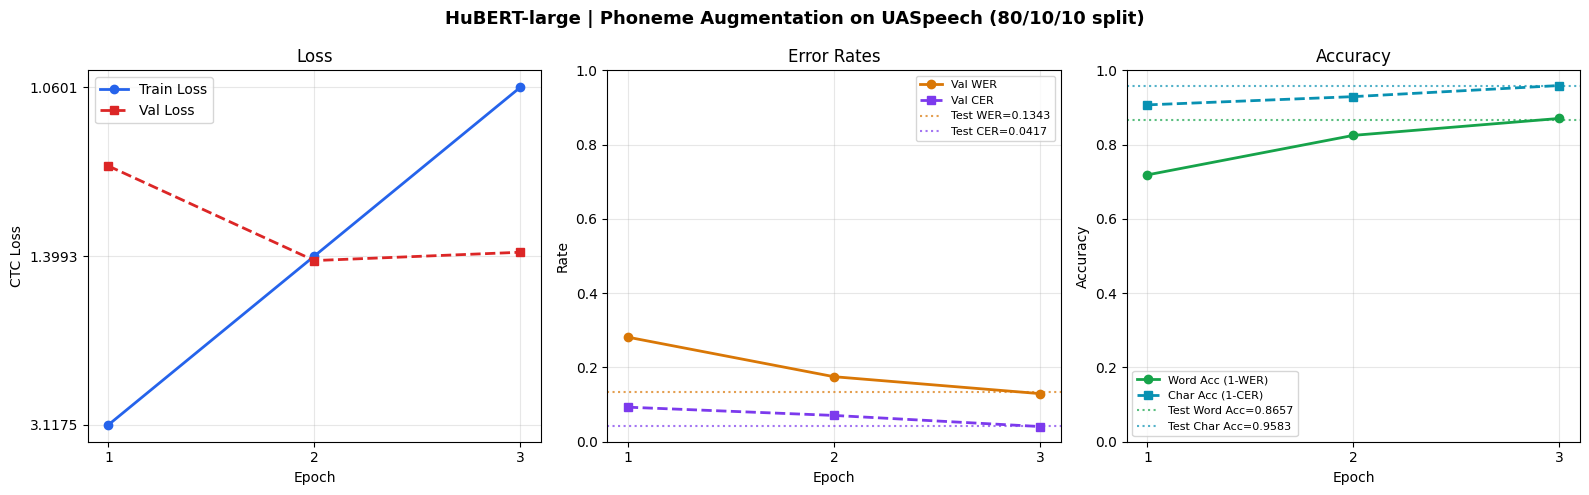

Saved → phoneme_results.png


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load phoneme results ──────────────────────────────────────────────
df = pd.read_csv("results_phoneme.csv")

# Separate training epochs from test row
df_epochs = df[df["epoch"] != "test"].copy()
df_epochs["epoch"]         = df_epochs["epoch"].astype(int)
df_epochs["word_accuracy"] = 1 - df_epochs["wer"]
df_epochs["char_accuracy"] = 1 - df_epochs["cer"]

# Get test results
df_test = df[df["epoch"] == "test"]
test_wer = float(df_test["wer"].values[0]) if len(df_test) > 0 else None
test_cer = float(df_test["cer"].values[0]) if len(df_test) > 0 else None

epochs = df_epochs["epoch"]

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "HuBERT-large | Phoneme Augmentation on UASpeech (80/10/10 split)",
    fontsize=13, fontweight="bold"
)

# Panel 1 — Loss
axes[0].plot(epochs, df_epochs["train_loss"], "o-", label="Train Loss", color="#2563eb", linewidth=2)
axes[0].plot(epochs, df_epochs["val_loss"],   "s--", label="Val Loss",  color="#dc2626", linewidth=2)
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 2 — Error rates + test point
axes[1].plot(epochs, df_epochs["wer"], "o-",  label="Val WER", color="#d97706", linewidth=2)
axes[1].plot(epochs, df_epochs["cer"], "s--", label="Val CER", color="#7c3aed", linewidth=2)
if test_wer is not None:
    axes[1].axhline(test_wer, color="#d97706", linestyle=":", alpha=0.7,
                    label=f"Test WER={test_wer:.4f}")
    axes[1].axhline(test_cer, color="#7c3aed",  linestyle=":", alpha=0.7,
                    label=f"Test CER={test_cer:.4f}")
axes[1].set_title("Error Rates"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Rate"); axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 3 — Accuracy
axes[2].plot(epochs, df_epochs["word_accuracy"], "o-",  label="Word Acc (1-WER)", color="#16a34a", linewidth=2)
axes[2].plot(epochs, df_epochs["char_accuracy"], "s--", label="Char Acc (1-CER)", color="#0891b2", linewidth=2)
if test_wer is not None:
    axes[2].axhline(1-test_wer, color="#16a34a", linestyle=":", alpha=0.7,
                    label=f"Test Word Acc={1-test_wer:.4f}")
    axes[2].axhline(1-test_cer, color="#0891b2",  linestyle=":", alpha=0.7,
                    label=f"Test Char Acc={1-test_cer:.4f}")
axes[2].set_title("Accuracy"); axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy"); axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("phoneme_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → phoneme_results.png")